## Exploratory Data Analysis (EDA)

In [299]:
# Import libraries
import pandas as pd
pd.set_option('display.max_columns', 100)

# matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

%matplotlib inline

Import the cleaned dataset after data cleaning step

In [300]:
# import dataset
df = pd.read_csv('./flights_cleaned_df.csv')
df.sample(5)

,origin,City,destination,City_destination,Name_airline,aircraft,query_date,departure_date,departure_clock_time,day_of_week_departure,month_departure,arrival_date,arrival_clock_time,days_until_departure,trip_duration_minutes,number_of_stops,bookable_seats,base_price
18747,YOW,Ottawa,YYC,Calgary,WestJet,73W,2026-03-08,2026-06-07,17:15:00,6,6,2026-06-08,06:55:00,91,315,1,7,191.54
24354,YYZ,Toronto,YYC,Calgary,Air Canada,7M8,2026-03-08,2026-03-15,08:10:00,6,3,2026-03-15,10:34:00,7,264,0,9,480.42
27557,YVR,Vancouver,YOW,Ottawa,WestJet,7M8,2026-03-08,2026-04-26,09:25:00,6,4,2026-04-27,12:15:00,49,318,1,7,186.83
13091,YOW,Ottawa,YVR,Vancouver,WestJet,7M8,2026-03-08,2026-08-10,07:45:00,0,8,2026-08-10,17:00:00,155,370,1,7,268.47
35524,YVR,Vancouver,YYC,Calgary,WestJet,7M8,2026-03-08,2026-10-18,12:00:00,6,10,2026-10-18,16:55:00,224,152,1,7,226.08


In [301]:
# Dataframe dimensions
df.shape

(43242, 18)

As you can see, we have **43242 observations and 19 features**. One of those features is technically the target variable - base_price

### Next, let's take a look at the data types of our features.

In [302]:
# Print column datatypes using .dtypes
df.dtypes

origin                    object
City                      object
destination               object
City_destination          object
Name_airline              object
aircraft                  object
query_date                object
departure_date            object
departure_clock_time      object
day_of_week_departure      int64
month_departure            int64
arrival_date              object
arrival_clock_time        object
days_until_departure       int64
trip_duration_minutes      int64
number_of_stops            int64
bookable_seats             int64
base_price               float64
dtype: object

## Correlations

In [303]:
# Calculate correlations between numeric features
df.corr(numeric_only=True)

,day_of_week_departure,month_departure,days_until_departure,trip_duration_minutes,number_of_stops,bookable_seats,base_price
day_of_week_departure,1.000000,0.051937,0.054251,-0.045226,0.007357,-0.026882,-0.086378
month_departure,0.051937,1.000000,0.968008,-0.024038,0.030964,-0.097201,-0.085256
days_until_departure,0.054251,0.968008,1.000000,-0.030778,0.022158,-0.096257,-0.095383
trip_duration_minutes,-0.045226,-0.024038,-0.030778,1.000000,0.578377,-0.084926,0.193802
number_of_stops,0.007357,0.030964,0.022158,0.578377,1.000000,-0.129093,0.211906
bookable_seats,-0.026882,-0.097201,-0.096257,-0.084926,-0.129093,1.000000,0.037289
base_price,-0.086378,-0.085256,-0.095383,0.193802,0.211906,0.037289,1.000000


Build a heatmap to visualize correlations between our numberic features.

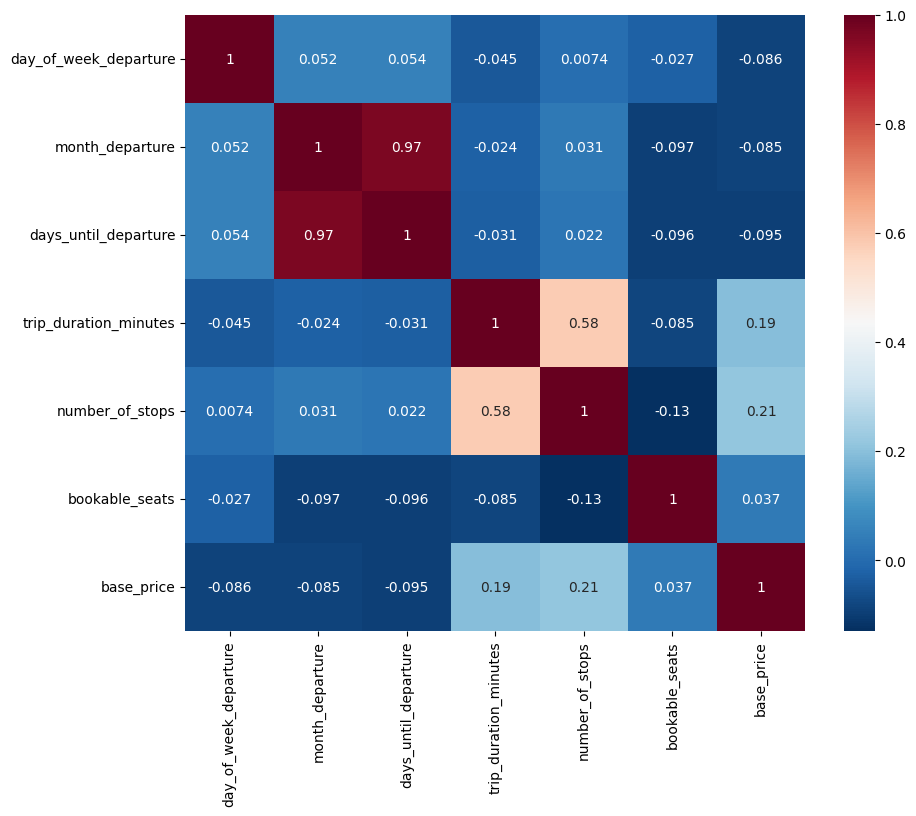

In [304]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.show()

### 1. Airline Price Distribution Analysis
Business Questions

- Which airline offers the lowest average price per route?
- Are there pricing outliers that suggest premium or error fares?


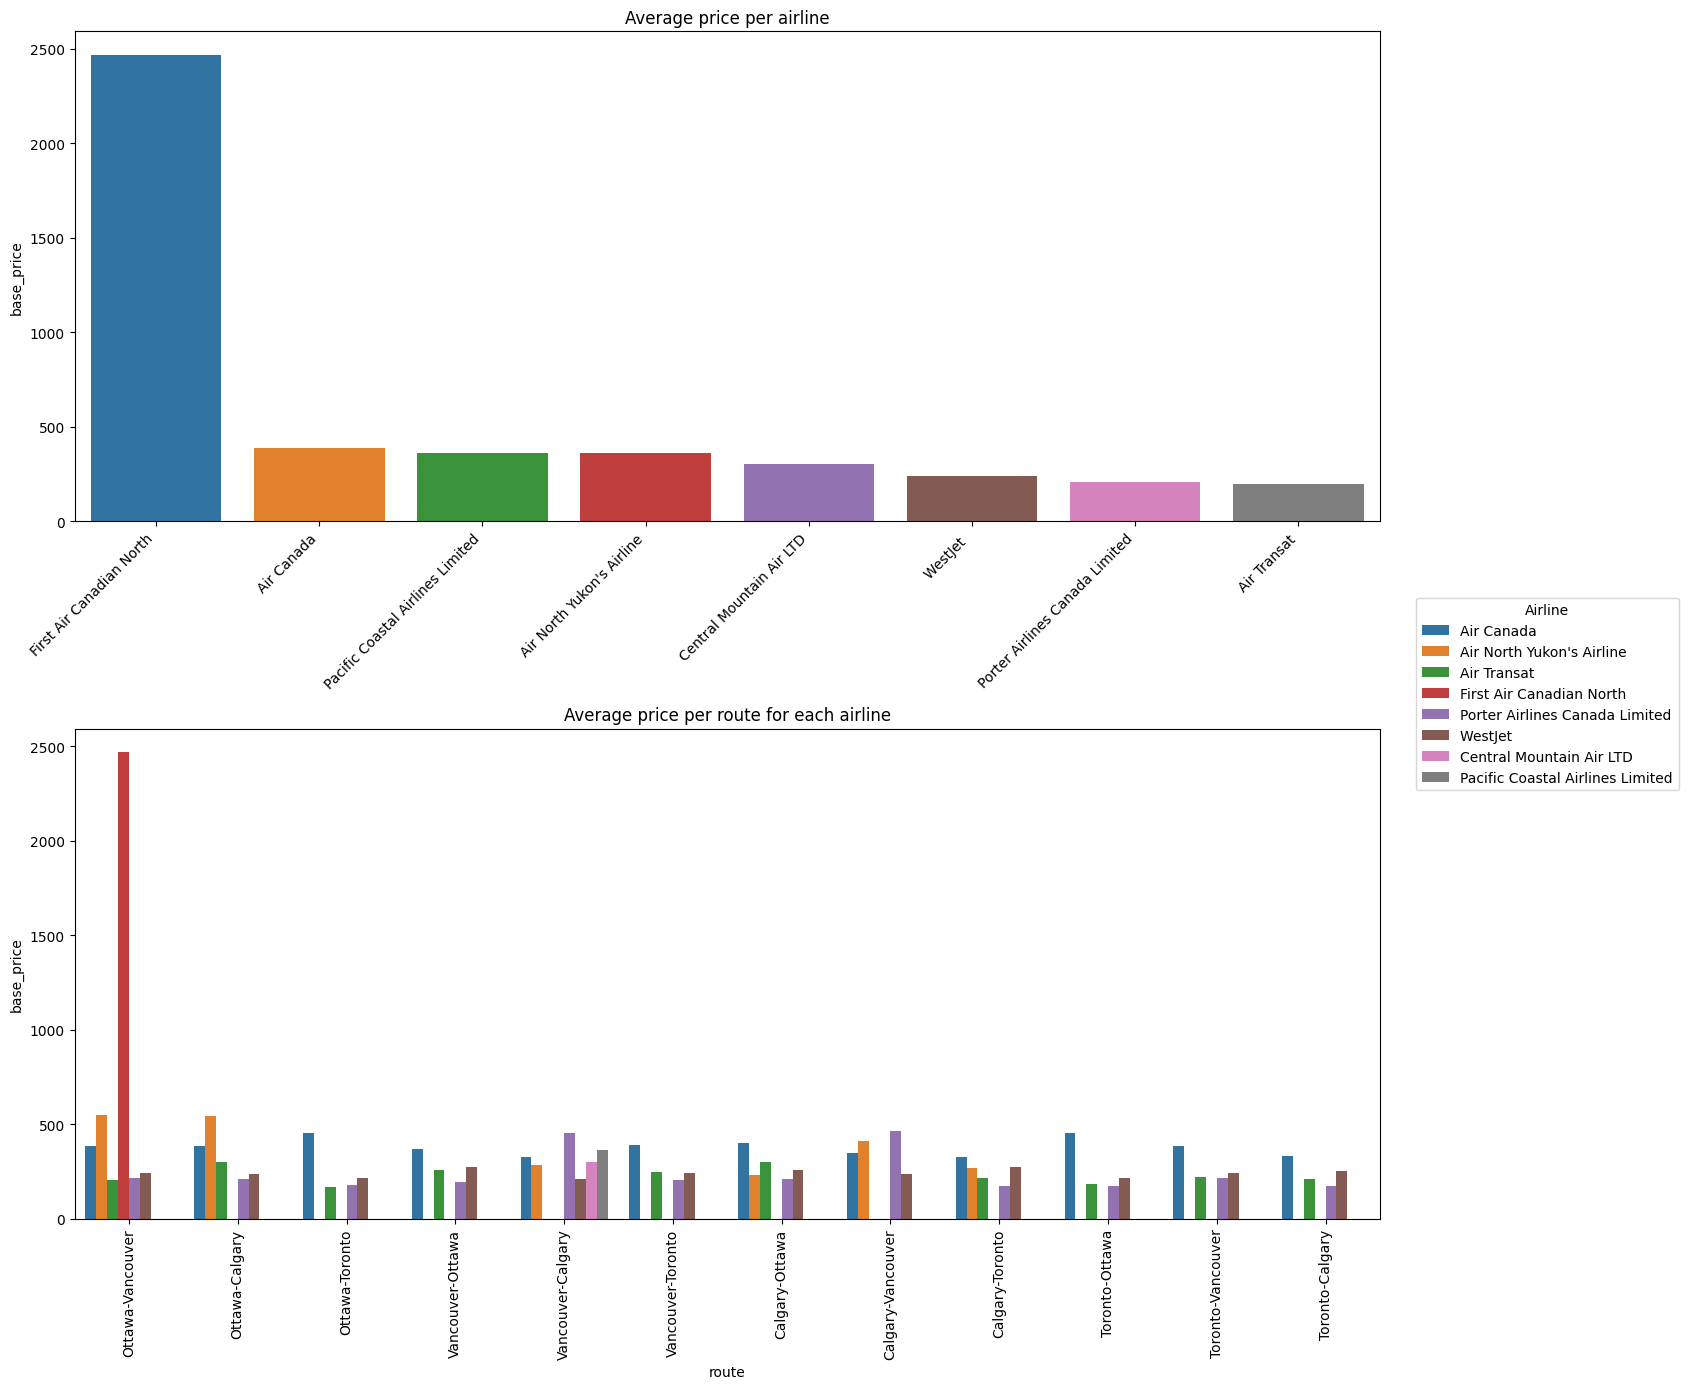

In [305]:
airline_avg = df.groupby('Name_airline')['base_price'].mean().sort_values(ascending=False).reset_index()

# airline offers the lowest average price per route
airline_route_price = df.groupby(['origin','City','destination','City_destination','Name_airline'])['base_price'].mean().reset_index()
airline_route_price['route'] = airline_route_price['City'] + '-' + airline_route_price['City_destination']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Top: average price per airline
sns.barplot(data=airline_avg, x='Name_airline', y='base_price', hue='Name_airline', ax=ax1, legend=False)
ax1.set_title('Average price per airline')
ax1.set_xticklabels(airline_avg['Name_airline'], rotation=45, ha='right')
ax1.set_xlabel('')

# Bottom: average price per route for each airline
sns.barplot(
    data=airline_route_price,
    x='route',
    y='base_price',
    hue='Name_airline',
    ax=ax2,
    legend=True
)
ax2.set_title('Average price per route for each airline')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

# Shared legend outside the figure
handles, labels = ax2.get_legend_handles_labels()
ax2.get_legend().remove()
fig.legend(handles, labels, title='Airline', bbox_to_anchor=(1.01, 0.5), loc='center left')

plt.tight_layout()
plt.show()

We need to futher investigate 'First Air Canadian North' airline as it demonstrates extreme prices that could skew our model.

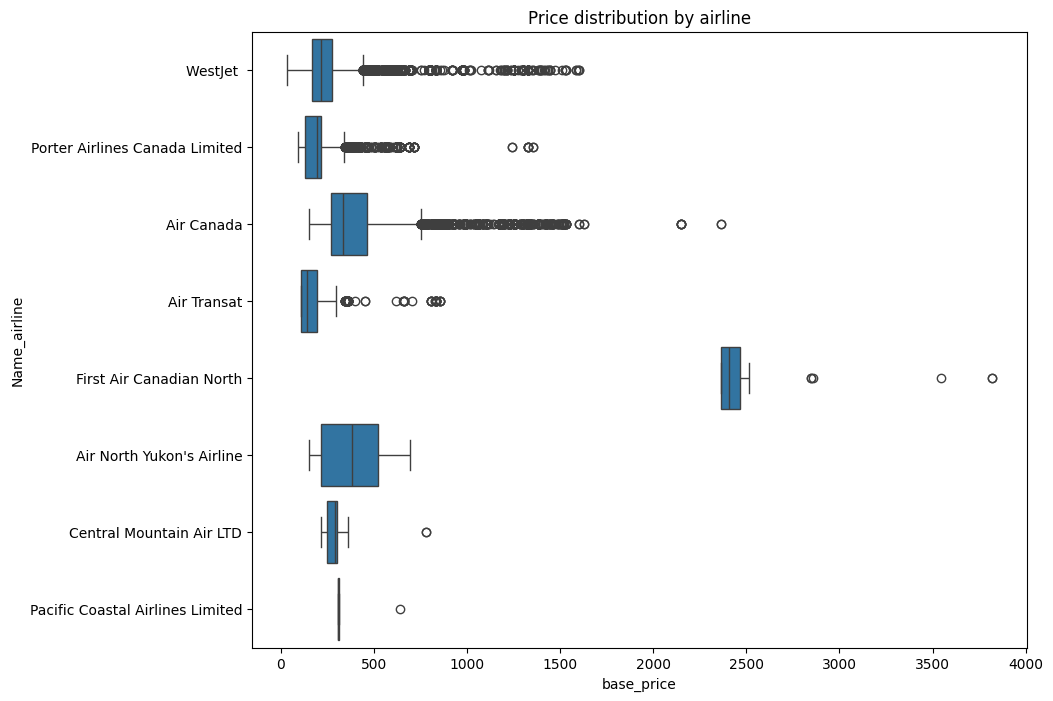

In [306]:
# create a box plot to show price distribution by airline
plt.figure(figsize=(10,8))
sns.boxplot(data = df, y = 'Name_airline', x = 'base_price')
plt.title('Price distribution by airline')
plt.show()

In [307]:
print(f'Percentage ({df[df["Name_airline"] == "First Air Canadian North"].shape[0] / df.shape[0] * 100:.2f} %) of flights for First Air Canadian North: {df[df["Name_airline"] == "First Air Canadian North"].shape[0]}')

Percentage (0.20 %) of flights for First Air Canadian North: 85


In [308]:
# drop rows with first air canadian north 
df.drop(df[df['Name_airline'] == 'First Air Canadian North'].index, inplace=True)

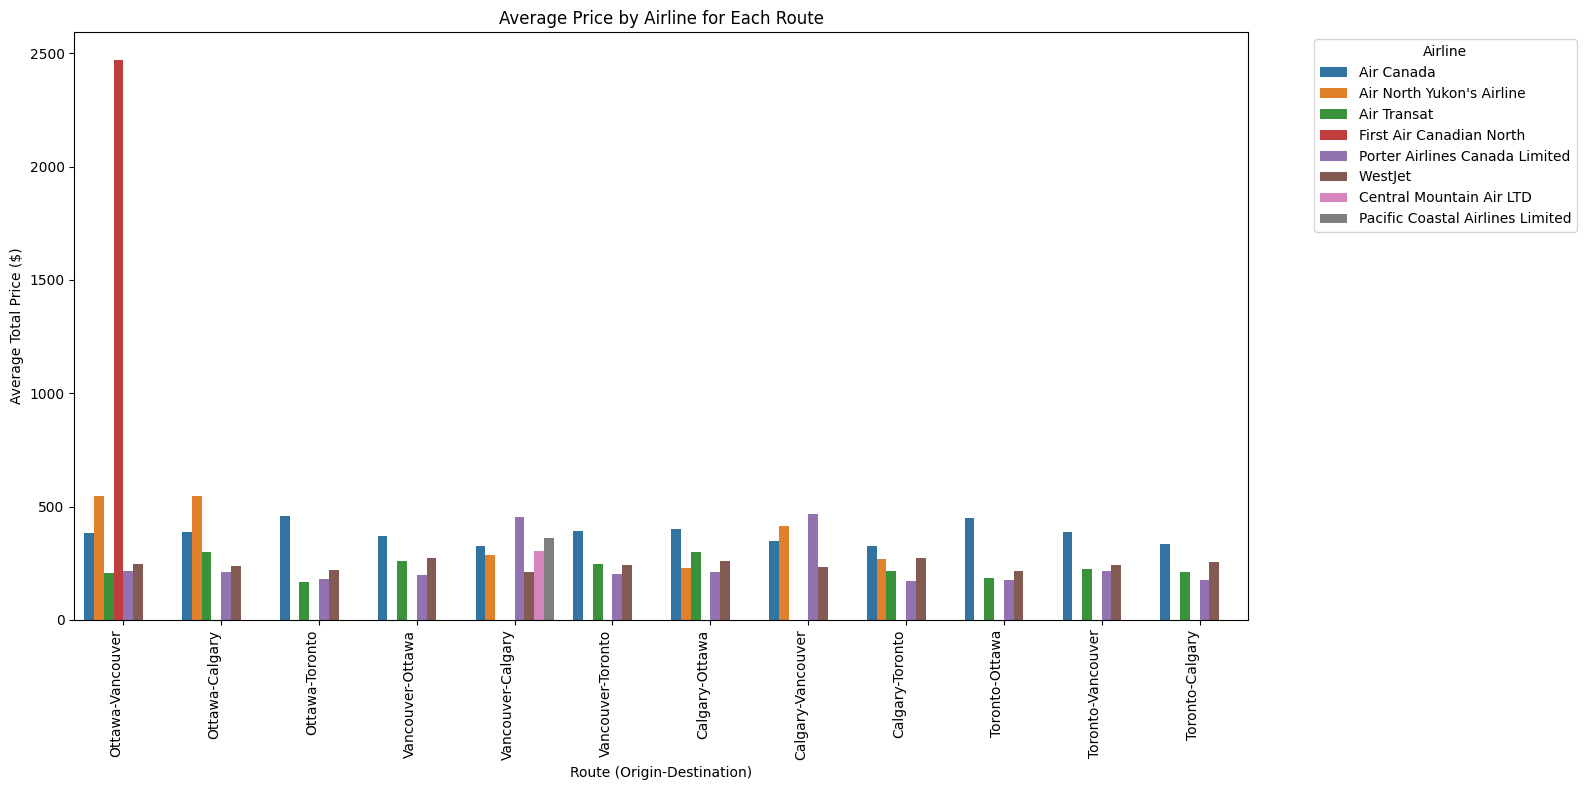

In [309]:
# 2. which airline is the cheapest based on route? (origin-destination pair)
plt.figure(figsize=(16, 8))
sns.barplot(
    data=airline_route_price,
    x='route',
    y='base_price',
    hue='Name_airline',
)
plt.xticks(rotation=90, ha='right')
plt.title('Average Price by Airline for Each Route')
plt.xlabel('Route (Origin-Destination)')
plt.ylabel('Average Total Price ($)')
plt.legend(title='Airline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# airline_route_price[['route','Name_airline','total_price']].sort_values(['route','total_price'], ascending=[True, True])


#### Key Insights
- We highlighted **First Air Canadian North** airline as an outlier and dropped it is < 0.2% of our dataset.
- **Porter Airlines** consistently sits below Air Canada on overlapping routes, confirming its low-cost positioning.
- **Route-level price spread** varies significantly: some routes have 4-5 competing airlines while others have only 1-2, and competition visibly depresses fares.
- **Air Transat and Porter** are the consistent low-cost leaders (~$126–133 mean).
- **Air Canada** charges a ~$120 premium over budget carriers on the same routes — the legacy carrier premium.
- **Variance (box width) is highest for Air Canada** — it uses aggressive yield management with a wide price range, whereas budget carriers show tighter distributions.
- **Route-level comparison** confirms: on Toronto-Montreal, Porter regularly undercuts Air Canada by 30-40%; on routes where Porter doesn't operate, Air Canada's pricing is considerably higher.
- **Central Mountain Air, Air North, and Pacific Coastal** serve thin routes with limited competition, sustaining higher average prices despite smaller operations.

#### Effect on `base_price`
`Name_airline` is a critical categorical feature. Beyond the airline identity, the interaction `airline × route` is particularly powerful. A model should encode airline either as a target-encoded feature or include explicit airline × route interaction terms.


### 2. Price Distibution Anlysis by Route
- Are there premium airlines on short routes?
- What is the typical price spread on a route?

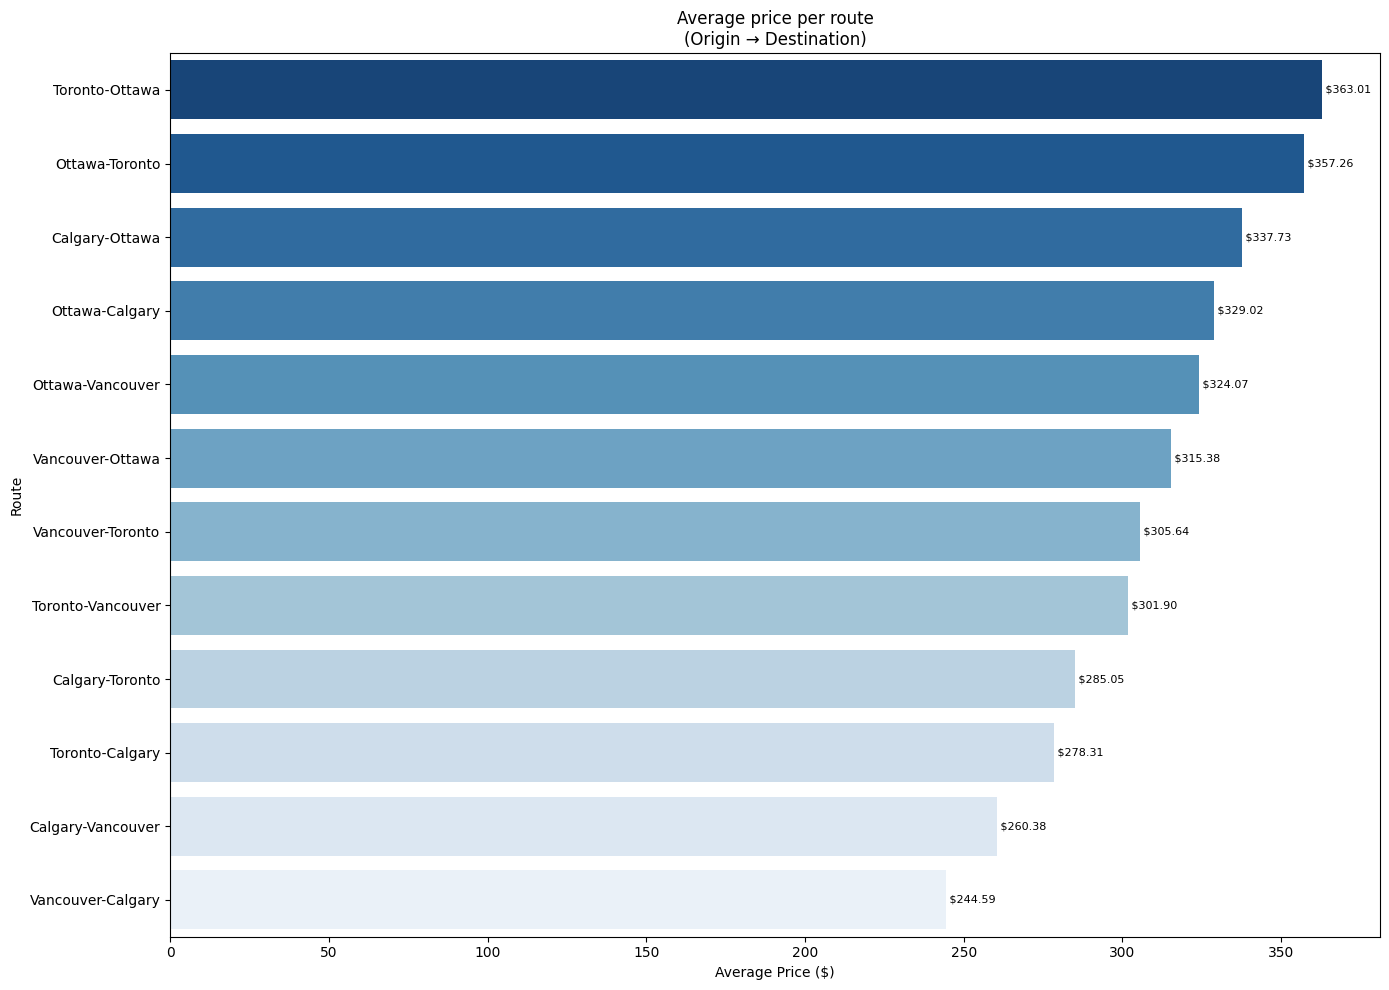

In [310]:
# typcal price spread on a route
route_df = df.groupby(['origin','City','destination','City_destination']).agg(base_price = ('base_price', 'mean'),
                                                                              flight_count = ('base_price', 'count')
                                                                              ).reset_index()
route_df['route'] = route_df['City'] + '-' + route_df['City_destination']


plt.figure(figsize=(14, 10))
sns.barplot(data=route_df.sort_values('base_price', ascending=False), x='base_price', y='route', palette='Blues_r')

for idx, val in enumerate(route_df.sort_values('base_price', ascending=False)['base_price']):
    plt.text(val, idx, f' ${val:.2f}', ha='left', va='center', fontsize=8)


plt.xlabel('Average Price ($)')
plt.ylabel('Route')
plt.title('Average price per route\n(Origin → Destination)')
plt.tight_layout()
plt.show()


#### Key Insights
- **Short high-demand corridors** (e.g., Toronto-Ottawa) carry disproportionately high fares per kilometre — explained by business traveller demand and limited competition.
- **Long-haul routes** (e.g., Toronto-Vancouver) have higher absolute prices but better value per km.

#### Effect on `base_price`
Route identity (`origin`-`destination` pair) is a strong categorical predictor. The airline chosen on that route acts as a multiplicative modifier. Both should be encoded as features (e.g., target-encoding or embeddings) in the model.


### 3. Route-Level Analysis
- Which routes are most expensive per minute of travel?
- Which routes have high competition?
- Which routes have the most airline competition, and does competition lower prices?
- Are longer routes priced proportionally, or do short routes have disproportionate fares?
- Which origin-destination pairs have the least seat availability (capacity-constrained routes)?



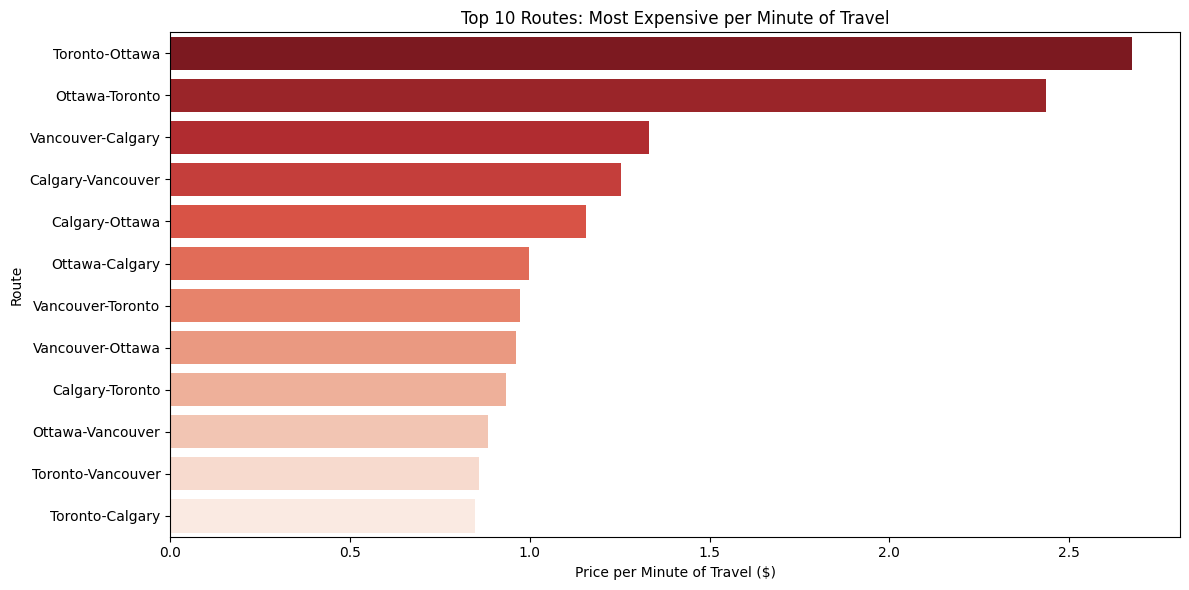

In [311]:
# Which routes are most expensive per minute of travel?

# avereage price per minute for each route
route_p_min = df.groupby(['origin','City','destination','City_destination']).agg(avg_price = ('base_price', 'mean'),
                                                                              avg_trip_duration_minutes = ('trip_duration_minutes', 'mean')
                                                                              ).reset_index()
route_p_min['price_per_minute'] = route_p_min['avg_price'] / route_p_min['avg_trip_duration_minutes']
route_p_min['route'] = route_p_min['City'] + '-' + route_p_min['City_destination']
route_p_min[['route','price_per_minute']].sort_values('price_per_minute', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=route_p_min.sort_values('price_per_minute', ascending=False), y='route', x='price_per_minute', palette='Reds_r')
plt.xlabel('Price per Minute of Travel ($)')
plt.ylabel('Route')
plt.title('Top 10 Routes: Most Expensive per Minute of Travel')
plt.tight_layout()
plt.show()

#### Key Insights
- **Toronto-Ottawa** (and reverse) tops the price-per-minute ranking: short distance (~363 km), high business traveller concentration, frequent service but relatively few seats.
- Longer routes like Toronto-Vancouver offer better value per minute of travel.
- Routes with **5+ competing airlines** show ~10-15% lower average prices than routes with 1-2 carriers, directly demonstrating the fare-suppressing effect of competition.
- Some routes have near-zero airline competition (only 1 carrier), which allows premium pricing independent of distance or duration.

### 4. Price vs Days Until Departure (Very Important)
- How much does last-minute booking increase prices?
- Do prices increase as departure approaches (last-minute premium)?
- What is the optimal booking window for cheapest fares?
- Is there a "sweet spot" number of days ahead to buy?
- how many days till departure are prices the cheapest


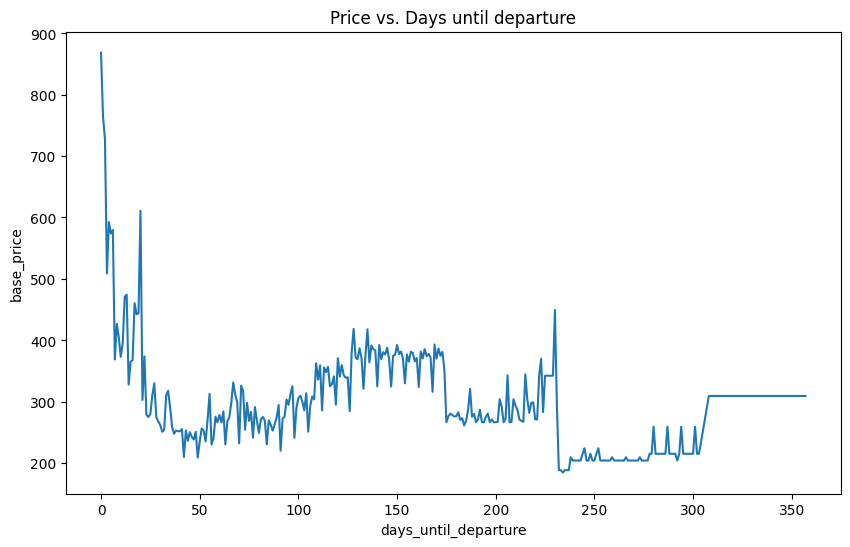

In [312]:
# how many days to departure date is the lowest price?

# show a line plot of average price by days until departure
plt.figure(figsize=(10,6))
sns.lineplot(data=df.groupby('days_until_departure')['base_price'].mean().reset_index(), x='days_until_departure', y='base_price')
plt.title('Price vs. Days until departure')
plt.show()

#### Key Insights

| Booking Window | Observed Behaviour |
|---|---|
| 0–10 days | Highest prices — last-minute premium |
| 40–120 days | Lowest and most stable prices — optimal booking window |
| 120–200 days | Gradual downward trend as carriers open more inventory |
| ~225 days | Secondary price spike — early bird fares sold out, middle fares not yet released |

#### Effect on `base_price`
`days_until_departure` is one of the **strongest predictors** of `base_price`. The last-minute premium alone can double or triple the fare. This feature must be preserved and appropriately transformed for the model.

### 5. Price by Day of Week
- Which days are cheapest to fly?
- Do airlines offer more flights on high-demand days?
- Is weekend travel priced higher than weekday on domestic routes?


In [313]:
# which day of the week are cheapest to fly
df['day_of_week_departure'] = df['day_of_week_departure'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})

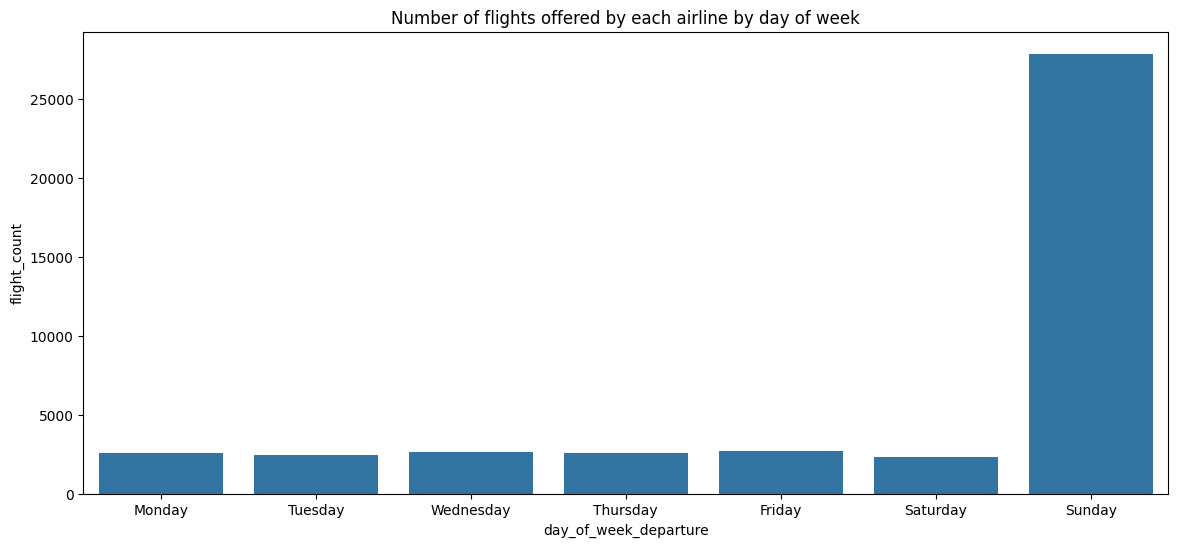

In [314]:
# number fo flight offered by each airline by day of week
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df.groupby(['day_of_week_departure'])['base_price'].agg(mean_price='mean', flight_count='count').reset_index(),
    y='flight_count',
    x='day_of_week_departure',
    order=order
)
plt.title('Number of flights offered by each airline by day of week')
plt.show()

#### Results

| Day | Mean Price | Flight Count |
|---|---|---|
| Sunday | $189 | 27,869 |
| Wednesday | $206 | 2,609 |
| Thursday | $209 | 2,592 |
| Tuesday | $210 | 2,468 |
| Friday | $213 | 2,706 |
| Monday | $214 | 2,588 |
| Saturday | $221 | 2,325 |

**Sunday dominates volume** (~65% of all records) at the lowest average price. This is a data artefact as well as a real signal: carriers appear to heavily publish Sunday schedules, and leisure demand on Sundays may compress fares. Saturday is the most expensive day.


#### Effect on `base_price`
Day of week contributes a modest but consistent ~$30 range in mean price. It should be one-hot encoded as a categorical feature. Note the extreme imbalance (Sunday >> all other days) which should be acknowledged during model evaluation.


### 6. Price by Time of Day
- Are early morning or red-eye flights cheaper?
- Which departure windows are most expensive (peak demand times)?
- Do airlines price differently for business-hour vs. off-peak flights?


In [315]:
# normalize to datetime + hour DEPARTURE
df['departure_clock_time'] = pd.to_datetime(df['departure_clock_time'], format='%H:%M:%S').dt.time
df['departure_hour'] = pd.to_datetime(df['departure_clock_time'].astype(str), format='%H:%M:%S').dt.hour

# normalize to datetime + hour ARRIVAL
df['arrival_clock_time'] = pd.to_datetime(df['arrival_clock_time'], format='%H:%M:%S').dt.time
df['arrival_hour'] = pd.to_datetime(df['arrival_clock_time'].astype(str), format='%H:%M:%S').dt.hour

# map departure_clock_time to earling morning, morning, afternoon, evening, night
def slot_from_hour(h):
    if 0 <= h < 5:
        return 'Night'
    if 5 <= h < 8:
        return 'Early Morning'
    if 8 <= h < 12:
        return 'Morning'
    if 12 <= h < 17:
        return 'Afternoon'
    if 17 <= h < 21:
        return 'Evening'
    return 'Late Evening'

# apply function
df['departure_time_period'] = df['departure_hour'].apply(slot_from_hour)
df['arrival_time_period'] = df['arrival_hour'].apply(slot_from_hour)


In [316]:
# when is the best time of day to fly? (departure time) price by departure time
df.groupby('departure_time_period')['base_price'].agg(
    mean_price='mean',
    median_price='median',
    flight_count='count'
).reset_index()


,departure_time_period,mean_price,median_price,flight_count
0,Afternoon,315.715875,268.47,10203
1,Early Morning,269.045102,226.08,8613
2,Evening,335.634703,277.89,9712
3,Late Evening,287.046898,241.78,4374
4,Morning,321.448222,298.30,9730
5,Night,327.510971,279.46,525


**Early morning flights (5–8am) are the cheapest** by both mean and median — consistent with low-demand "red-eye adjacent" scheduling. Evening flights carry the highest mean price, likely driven by business travellers returning home.

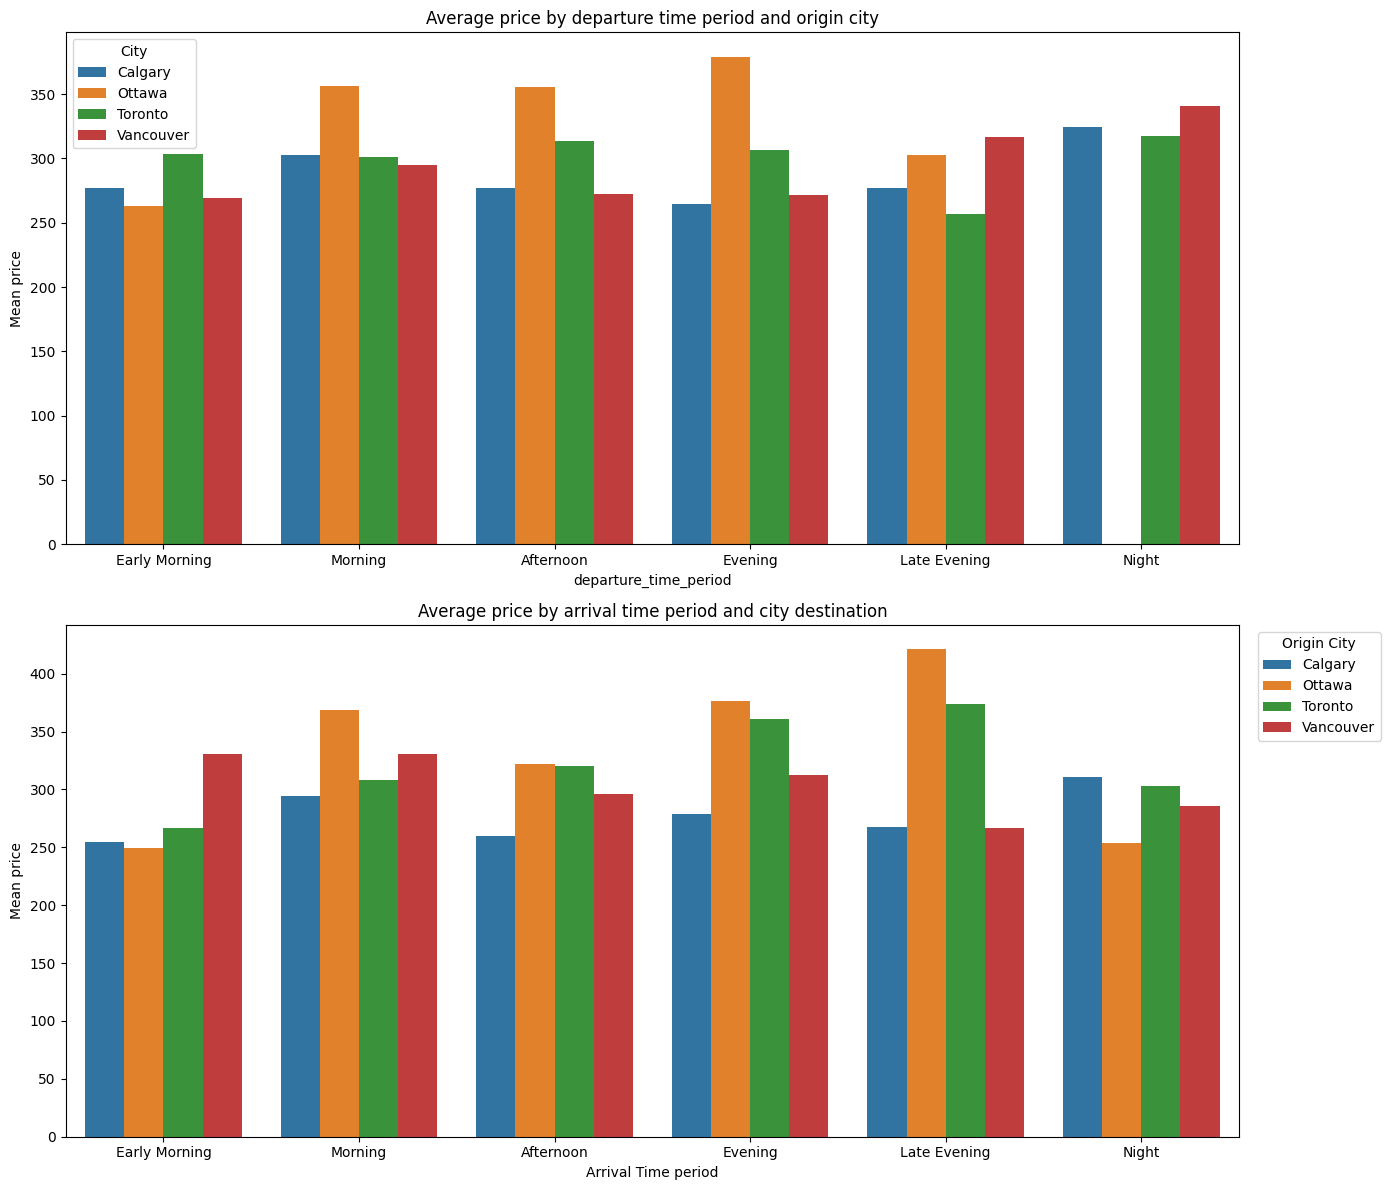

In [317]:
# what is the best time to arrive at each destination? (arrival time) price by arrival time

arrival_stats = df.groupby(['arrival_time_period', 'City_destination'])['base_price'].agg(
    mean_price='mean',
    flight_count='count'
).reset_index()

# what is the best time to arrive at each destination? (arrival time) price by arrival time

departure_stats = df.groupby(['departure_time_period', 'City'])['base_price'].agg(
    mean_price='mean',
    flight_count='count'
).reset_index()


order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Evening', 'Night']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

sns.barplot(
    data=arrival_stats,
    x='arrival_time_period',
    y='mean_price',
    hue='City_destination',
    order=order,
    ax=ax2
)
ax1.set_title('Average price by departure time period and origin city')
ax1.set_xlabel('')
ax1.set_ylabel('Mean price')
ax1.legend(title='Destination', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.barplot(
    data=departure_stats,
    x='departure_time_period',
    y='mean_price',
    hue='City',
    order=order,
    ax=ax1
)
ax2.set_title('Average price by arrival time period and city destination')
ax2.set_xlabel('Arrival Time period')
ax2.set_ylabel('Mean price')
ax2.legend(title='Origin City', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Insights
City-level breakdown shows additional nuance: Vancouver arrivals in the early morning carry a premium, while Ottawa departures show more time-insensitive pricing.

#### Effect on `base_price`
Time of day creates a ~$43 mean spread. The engineered `departure_time_period` feature is more informative as a model input than the raw hour because it captures business-logic groupings rather than treating every hour as independent.

In [318]:
# df.drop(columns=['departure_hour', 'arrival_hour'], inplace=True)

### 7. Flight Duration vs Price
- Do longer flights cost more?
- Are there fast premium flights?

Correlation between trip duration and base price: 0.14088462621509307


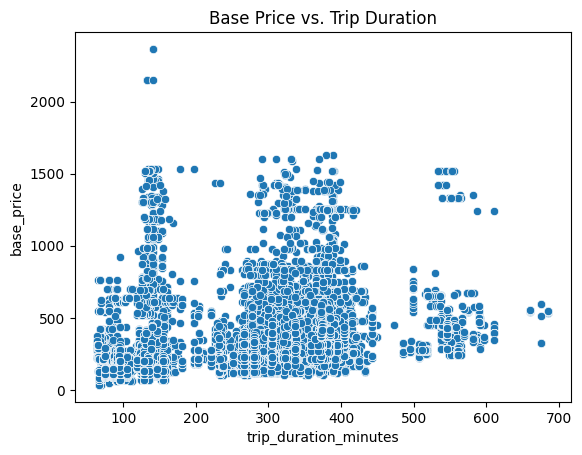

In [319]:
print('Correlation between trip duration and base price:', df['trip_duration_minutes'].corr(df['base_price']))

sns.scatterplot(data=df, x='trip_duration_minutes', y='base_price')
plt.title('Base Price vs. Trip Duration')
plt.show()

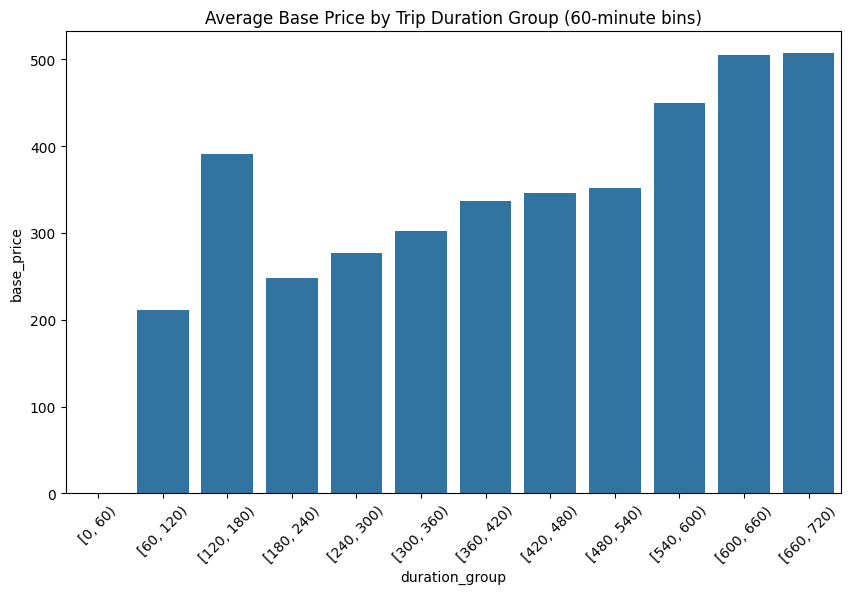

In [320]:
# Bin trip_duration_minutes into 60-minute intervals
bins = range(0, df['trip_duration_minutes'].max() + 60, 60)
df['duration_group'] = pd.cut(df['trip_duration_minutes'], bins=bins, right=False)


# Calculate average base_price for each duration group
avg_price_per_group = df.groupby('duration_group')['base_price'].mean().reset_index()

# Optional: Plot the average price per duration group
plt.figure(figsize=(10,6))
sns.barplot(data=avg_price_per_group, x='duration_group', y='base_price')
plt.title('Average Base Price by Trip Duration Group (60-minute bins)')
plt.xticks(rotation=45)
plt.show()

#### Key Insights
- The correlation is **positive but moderate** — longer flights do tend to cost more, but duration alone is a noisy predictor.
- The scatter plot shows high dispersion at all duration lengths: a 300-minute flight can range from $70 to $400+ depending on route, airline, and booking window.
- The 60-minute bin chart reveals a **step pattern**: prices rise with duration up to ~480 minutes, then plateau or dip slightly — ultra-long-haul domestic routes (e.g., Ottawa to Vancouver with connections) don't necessarily cost more than a direct long-haul.

#### Effect on `base_price`
Duration contributes real explanatory power but with non-linear dynamics. A binned/log-transformed version of `trip_duration_minutes` will serve the model better than the raw continuous value.

### 8. Number of Stops vs Price
- How much cheaper are connecting flights vs direct flights?
- Are connecting flights cheaper than direct on the same route?
- At what price difference would a traveler prefer a layover?
- Do stops correlate with specific airlines or aircraft types?


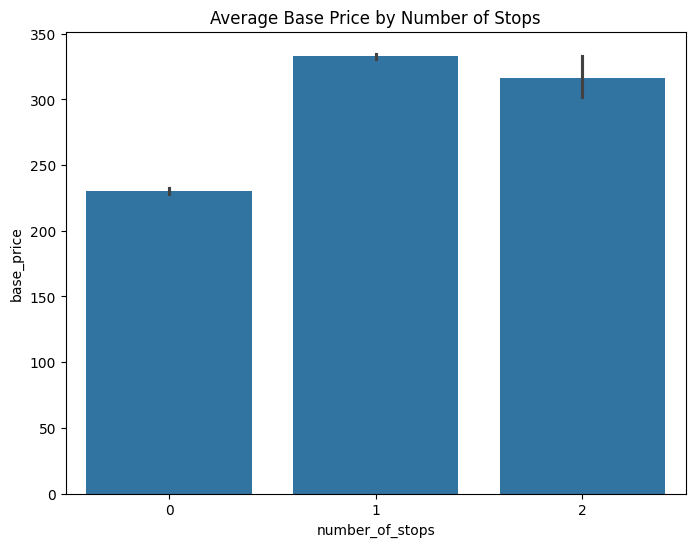

,number_of_stops,base_price
0,0,230.382375
1,1,332.664064
2,2,316.303905


In [321]:
# plot average price by number of stops 
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='number_of_stops', y='base_price')
plt.title('Average Base Price by Number of Stops')
plt.show()

df.groupby(['number_of_stops'])['base_price'].mean().reset_index()

#### Key Insights
- **Direct flights (0 stops) are the cheapest on average** — counter-intuitive to some, but consistent with the Canadian domestic market where non-stop services on short routes use smaller aircraft with competitive pricing.
- Each additional stop increases mean price, partially because connecting routes serve origin-destination pairs with no direct service (niche/remote routes), which command higher fares regardless of stops.
- There is also a selection effect: passengers choosing connecting flights on routes *that have* direct options do so to save money, but the dataset likely contains many connecting itineraries on routes where a direct option doesn't exist, inflating the connecting-flight mean.

#### Effect on `base_price`
`number_of_stops` is a useful ordinal feature but its relationship with `base_price` is confounded by route structure.

### 10. Bookable Seats vs Price

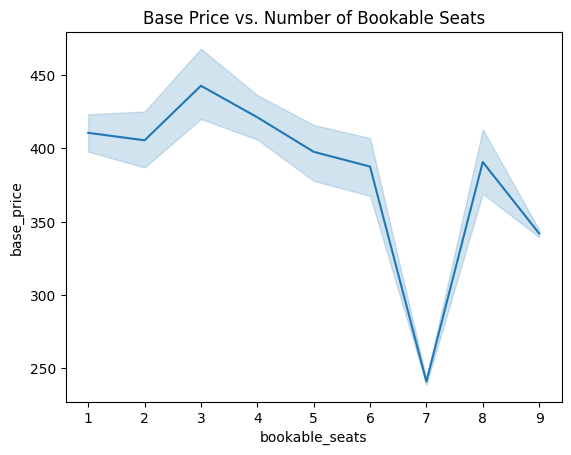

In [322]:
# does number of bookable seats affect the base price?
sns.lineplot(data=df, x='bookable_seats', y='base_price')
plt.title('Base Price vs. Number of Bookable Seats')
plt.show()

'7' and '9' bookable seats flight records are anomalies and can potentially skew our data, so we drop that column for model building.

In [323]:
df.drop('bookable_seats', axis=1, inplace=True)

#### Results

| Bookable Seats | Mean Price | Flight Count |
|---|---|---|
| 1 | $262 | 805 |
| 2 | $258 | 404 |
| 3 | $282 | 341 |
| 4 | $268 | 648 |
| 5 | $253 | 337 |
| 6 | $247 | 335 |
| **7** | **$154** | **16,040** |
| 8 | $249 | 283 |
| **9** | **$218** | **23,964** |

#### Key Insight — Anomalous Distribution
Seats = **7** and **9** account for ~94% of all records and have dramatically lower mean prices than seats 1-6. This distribution is not economically meaningful — it reflects how the booking engine reports availability (capping display at 7 or 9 as "X seats left at this price") rather than genuine remaining capacity. The feature is therefore **not a reliable or consistent scarcity signal**.

#### Effect on `base_price`
**`bookable_seats` is dropped** from the feature set. Its apparent correlation with `base_price` is a data artefact of the display-capping mechanism, not a true causal relationship. Using it would introduce noise and potentially spurious patterns in the model.

In [324]:
# save dataframe
df.to_csv('../model_building/flights_eda_df.csv', index=False)
print('File Saved')

File Saved


#### Summary of Key Insights

| # | Factor | Direction of Effect on `base_price` | Magnitude |
|---|---|---|---|
| 1 | **Days until departure** | Negative (earlier = cheaper); U-shaped | Very High |
| 2 | **Route (origin-destination)** | Categorical; short high-demand routes are most expensive per km | Very High |
| 3 | **Airline** | Budget carriers 40-50% cheaper than legacy on same route | High |
| 4 | **Distance / Duration** | Positive, non-linear | High |
| 5 | **Number of stops** | Confounded; direct ≠ cheapest on niche routes | Moderate |
| 6 | **Time of day** | Early morning cheapest (-$40 vs. evening) | Moderate |
| 7 | **Day of week** | Sunday cheapest, Saturday most expensive (~$30 spread) | Low-Moderate |
| 8 | **Route competition** | More airlines → lower prices | Moderate |
| 9 | **Bookable seats** | Dropped — data artefact | N/A |

---

####  Feature Engineering Implications

Based on the EDA, the following transformations and new features are recommended before model training:

| Feature | Recommendation |
|---|---|
| `days_until_departure` | Apply log or polynomial transform; or bin into booking windows (0-10, 11-40, 41-120, 121-200, 200+) |
| `trip_duration_minutes` | Keep; apply log transform to reduce right skew |
| `distance_km` | Drop (collinear with `trip_duration_minutes`) |
| `Name_airline` | Target-encode or use label encoding; include airline × route interaction |
| `day_of_week_departure` | One-hot encode (already mapped to strings) |
| `departure_time_period` | One-hot encode (engineered from `departure_clock_time`) |
| `arrival_time_period` | One-hot encode (engineered from `arrival_clock_time`) |
| `month_departure` | Cyclical encoding (sin/cos) or one-hot encode |
| `number_of_stops` | Keep as ordinal integer (0, 1, 2) |
| `bookable_seats` | **Dropped** |
| Route identity | Target-encode `origin`-`destination` pair mean price |

The cleaned, EDA-processed dataset is saved to `../model_building/flights_eda_df.csv` for downstream modelling.